# Filter Robustness Analysis - Pathology Classification

## Objective
Test whether pathology classification results are robust to different preprocessing filter configurations.

## Filter Configurations Tested
- **original:** Standard preprocessing pipeline
- **remove_low_freq_artifacts:** Stricter low-frequency filtering
- **remove_high_freq_artifacts:** Stricter high-frequency filtering
- **strict_both_ends:** Stricter filtering on both ends
- **clinical_range:** Clinical EEG frequency range only

## Conclusion
Pathology classification performance is robust to filter choices, validating that findings generalize across preprocessing variations.

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /Users/chox/Documents/Studia/4_rok/ART/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
import joblib

from src.visualization.eeg_plots import plot_eeg_feature_overview
from src.visualization.shap_utils import compute_shap_from_pipeline, shap_to_mean_series

logging.basicConfig(level=logging.INFO, format='%(message)s')

RESULTS_PATH       = 'results/tables/06_filter_robustness/patho_clf_results.csv'
PIPELINE_SAVE_DIR  = 'models/06_filter_robustness/patho_clf_pipelines'
SHAP_DATA_SAVE_DIR = 'results/shap_data/06_filter_robustness/patho_clf'
FIGURES_DIR        = 'results/figures/06_filter_robustness/pathology_classification'

FEATURES = [
    'original',
    'remove_low_freq_artifacts',
    'remove_high_freq_artifacts',
    'strict_both_ends',
    'clinical_range',
]
COLOR_GRID = ['tomato', 'skyblue', 'green', 'orange', 'purple']

/Users/chox/Documents/Studia/4_rok/ART/eeg-site-effects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
results_df = pd.read_csv(RESULTS_PATH)

pivot = results_df.pivot_table(index='tag', columns='hospital', values='auc', aggfunc='mean')
sort_idx = pivot.loc['original'].values.argsort()[::-1]
hospitals_sorted = pivot.columns.values[sort_idx]

## Pathology AUC and MCC per hospital — per filter configuration

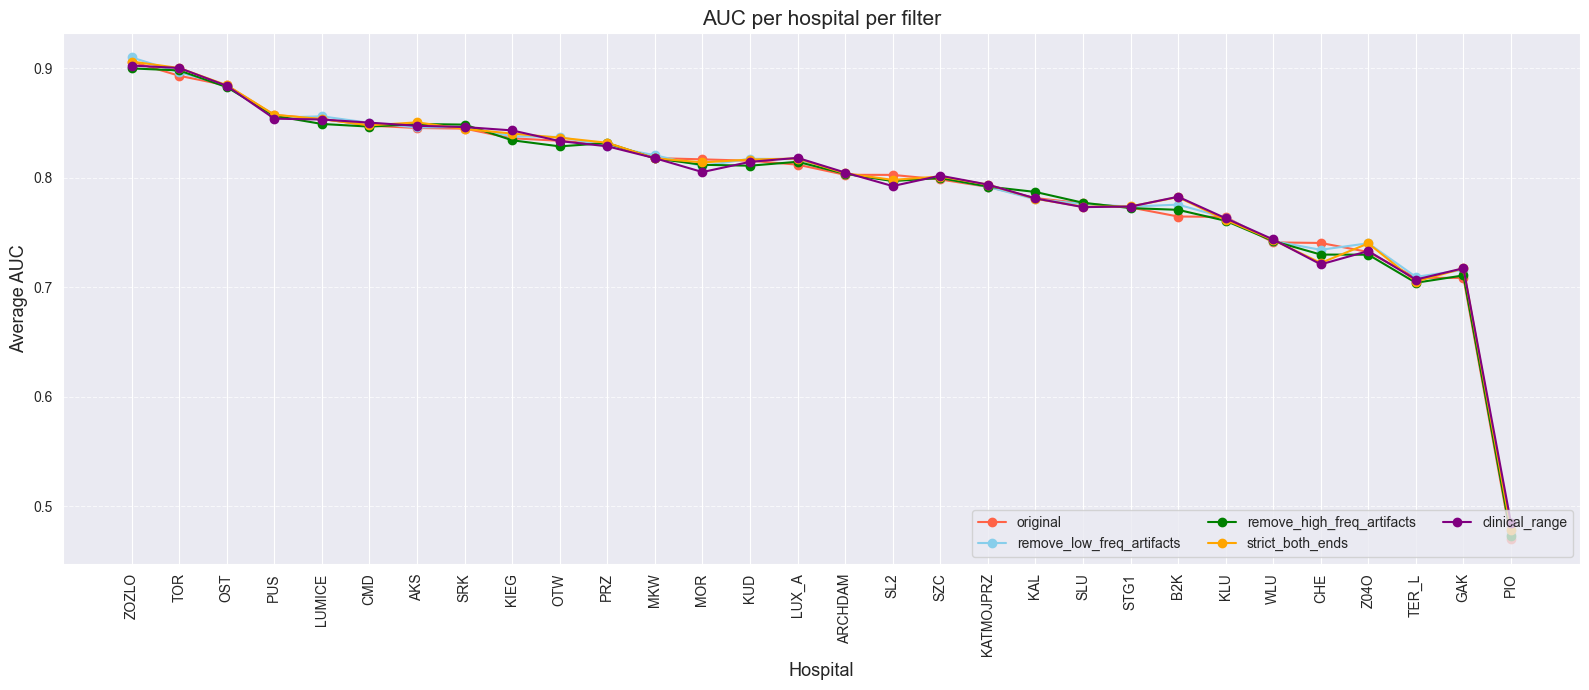

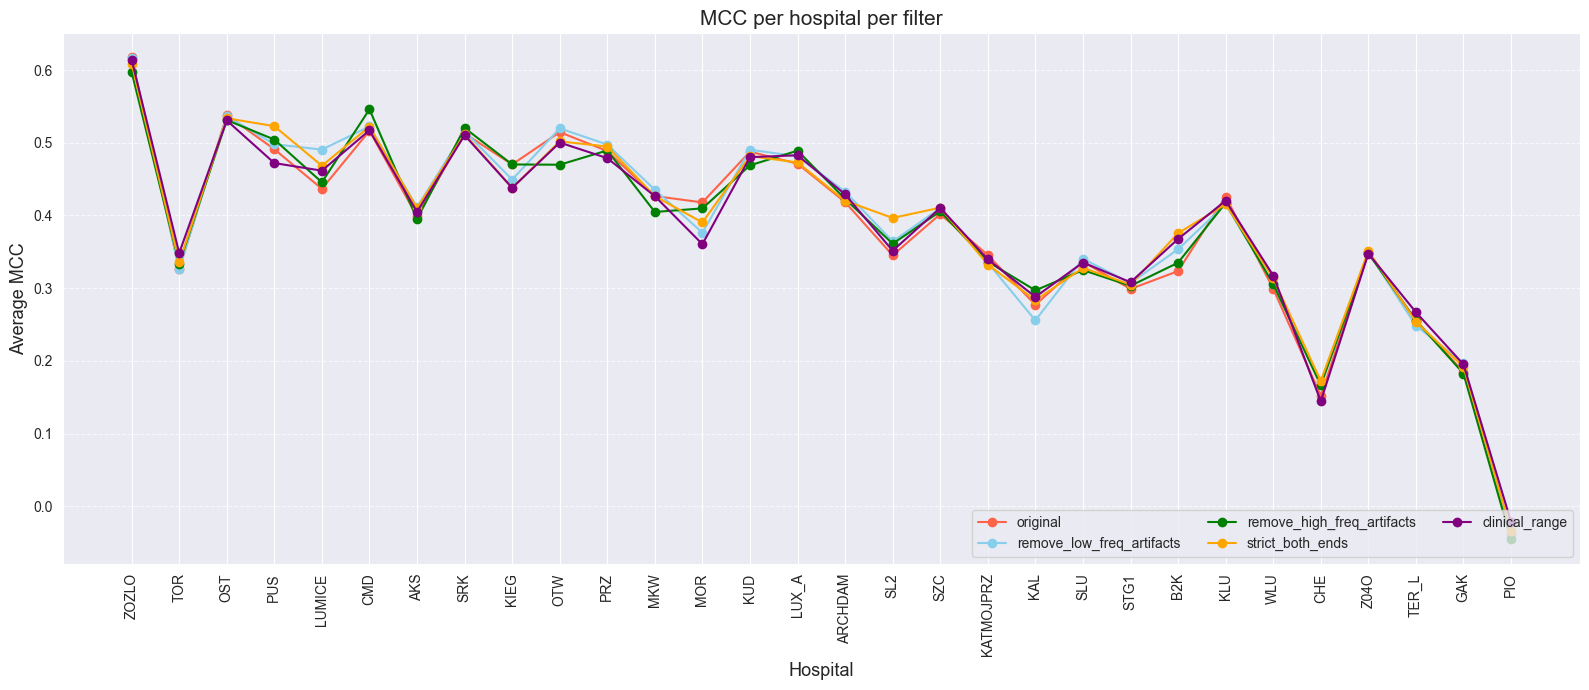

In [4]:
os.makedirs(FIGURES_DIR, exist_ok=True)

for metric in ['auc', 'mcc']:
    mean_df = results_df.pivot_table(
        index='tag', columns='hospital', values=metric, aggfunc='mean'
    )

    fig, ax = plt.subplots(figsize=(16, 7))
    for i, tag in enumerate(FEATURES):
        values = [mean_df.loc[tag].get(h, np.nan) for h in hospitals_sorted]
        ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
                color=COLOR_GRID[i % len(COLOR_GRID)], label=tag)

    ax.set_ylabel(f'Average {metric.upper()}', fontsize=13)
    ax.set_xlabel('Hospital', fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(loc='lower right', fontsize=10, ncol=3)
    ax.set_title(f'{metric.upper()} per hospital per filter', fontsize=15)
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/patho_{metric}_per_hospital.png', dpi=150, bbox_inches='tight')
    plt.show()

## SHAP Analysis

> **Server only** — requires saved pipelines and test data from `models/` and `results/shap_data/`

In [5]:
RUN = False
if RUN:
    pipelines = {}
    test_data = {}
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        pipelines[key] = {}
        test_data[key] = {}
        for hospital in hospitals_sorted:
            pipeline_path = os.path.join(PIPELINE_SAVE_DIR,
                f'{method}_{hospital}_{filter_tag}_pipeline.joblib')
            pipelines[key][hospital] = joblib.load(pipeline_path)

            data_path = os.path.join(SHAP_DATA_SAVE_DIR,
                f'{method}_{hospital}_{filter_tag}_test_data.parquet')
            test_data[key][hospital] = pd.read_parquet(data_path)

In [6]:
if RUN:
    shap_values = {}
    X_shap = {}
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        shap_values[key] = {}
        X_shap[key] = {}
        for hospital in hospitals_sorted:
            X_test = test_data[key][hospital].drop(columns=['y_true'])
            shap_values[key][hospital], X_shap[key][hospital] = compute_shap_from_pipeline(
                pipelines[key][hospital], X_test
            )
        logging.info(f'SHAP done: {filter_tag}')

In [7]:
if RUN:
    os.makedirs(FIGURES_DIR, exist_ok=True)
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        mean_series_list = [shap_to_mean_series(shap_values[key][h]) for h in hospitals_sorted]
        shap_series = pd.concat(mean_series_list, axis=1).mean(axis=1)
        fig, axs = plot_eeg_feature_overview(
            features_series=shap_series,
            figure_title=f'Filter: {filter_tag}'
        )
        save_path = f'{FIGURES_DIR}/{key}_shap_overview.png'
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        logging.info(f'Saved: {save_path}')
        plt.close(fig)

In [ ]:
if RUN:
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        for hospital_id in hospitals_sorted:
            shap_series = shap_to_mean_series(shap_values[key][hospital_id])
            fig, axs = plot_eeg_feature_overview(
                features_series=shap_series,
                figure_title=f'Filter: {filter_tag}, Hospital: {hospital_id}'
            )
            save_dir = f'{FIGURES_DIR}/{key}'
            os.makedirs(save_dir, exist_ok=True)
            fig.savefig(f'{save_dir}/{key}_{hospital_id}_shap_overview.png',
                        dpi=150, bbox_inches='tight')
            plt.close(fig)
        logging.info(f'Per-hospital SHAP saved: {filter_tag}')